# Age Verification with Computer Vision for Alcohol Sales Compliance

### Project Overview

Retailers that sell alcohol must comply with strict legal regulations that prohibit selling alcoholic beverages to individuals under the legal drinking age. In high-traffic supermarket environments, verifying age consistently can be challenging. Cashiers may rely on visual judgment or identification checks, which can lead to human error, slow checkout processes, or inconsistent enforcement of alcohol sales laws.

Good Seed, a supermarket chain, is exploring whether **data science and computer vision** can assist in improving compliance with these regulations. The stores are already equipped with cameras at checkout counters that activate when alcohol purchases occur. This creates an opportunity to apply **machine learning and computer vision techniques** to estimate a customer's age from a captured image and provide an automated layer of verification.

### Problem Statement

The core problem this project addresses is:

> **Can a computer vision model accurately estimate a customer's age from a photograph to help prevent alcohol sales to underage individuals?**

An effective solution could serve as a decision-support tool for cashiers by flagging potentially underage customers and prompting ID verification when necessary. This approach aims to reduce human error, improve regulatory compliance, and support responsible alcohol sales.

### Approach

To evaluate the feasibility of this solution, this project performs the following steps:

1. **Exploratory Data Analysis (EDA)**  
   Analyze a dataset of labeled facial images to understand the distribution of ages, dataset size, and potential biases or limitations in the data.

2. **Model Development**  
   Train a **deep learning computer vision model** capable of estimating a person's age from a facial image. Training is performed on a **GPU platform** to handle the computational demands of image processing and neural network training.

3. **Model Evaluation**  
   Assess the model's performance using appropriate metrics to determine how accurately it predicts age. This evaluation helps determine whether the model could realistically support alcohol sales compliance in retail environments.

4. **Results and Insights**  
   Interpret the model’s results, discuss strengths and limitations, and evaluate whether the approach is practical for real-world deployment.

### Expected Outcome

The final outcome of this project is a trained and evaluated computer vision model capable of predicting age from facial images. By analyzing the model’s performance, we can determine whether automated age estimation could serve as a **support tool for retail compliance systems**, helping Good Seed reduce the risk of selling alcohol to underage customers.

## Initialization

In [1]:
import pandas as pd 
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import os
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt


## Load Data

The dataset is stored in the `/datasets/faces/` folder, there you can find
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [2]:
data_path = '/faces/'
labels = pd.read_csv(os.path.join(data_path, 'labels.csv'))


In [3]:
print(labels.head())
print(labels.info())

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB
None


In [4]:
print(f"Total samples: {len(labels)}")


Total samples: 7591


In [5]:
print(f"Unique images: {labels['file_name'].nunique()}")


Unique images: 7591


In [6]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


## EDA

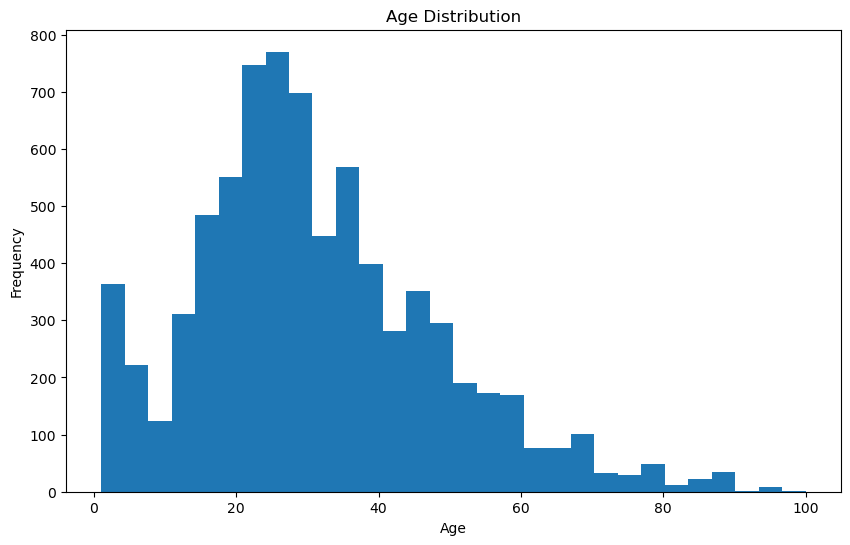

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(labels['real_age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [8]:
underage = labels[labels['real_age'] < 21]
legal = labels[labels['real_age'] >= 21]

print(f"Underage samples: {len(underage)}")
print(f"Legal age samples: {len(legal)}")

Underage samples: 2054
Legal age samples: 5537


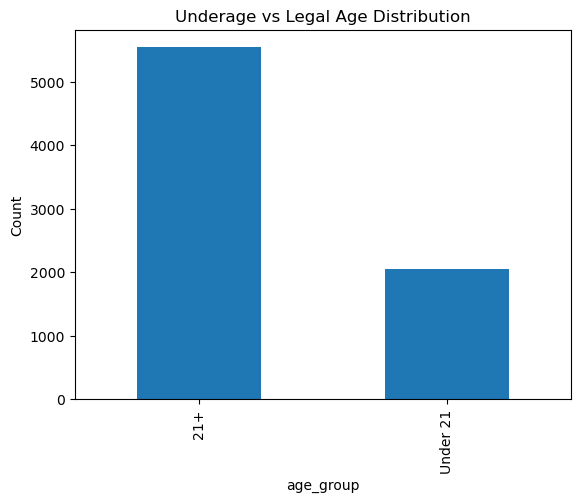

In [9]:
labels['age_group'] = labels['real_age'].apply(lambda x: 'Under 21' if x < 21 else '21+')

labels['age_group'].value_counts().plot(kind='bar')
plt.title('Underage vs Legal Age Distribution')
plt.ylabel('Count')
plt.show()

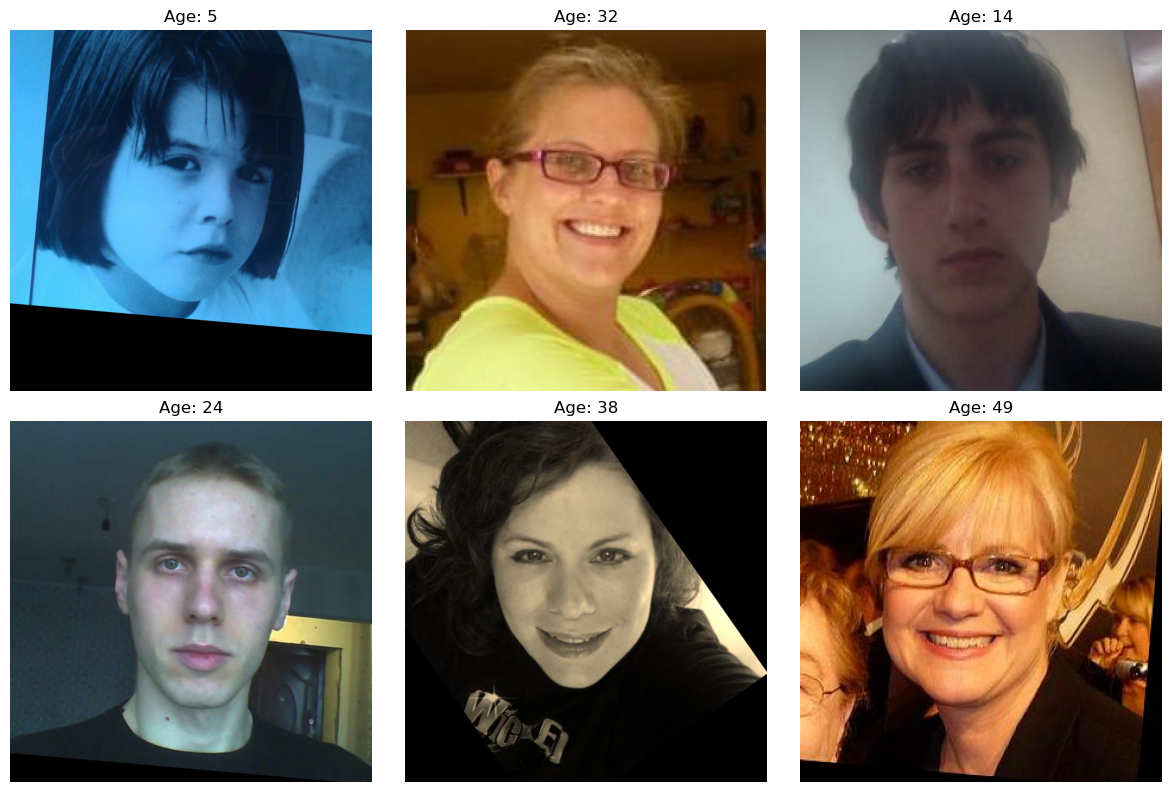

In [10]:
sample_images = labels.sample(6)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_images.iterrows()):
    img_path = os.path.join(data_path, 'final_files', row['file_name'])
    img = Image.open(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Age: {row['real_age']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
sizes = []

for i in range(100):  # sample for efficiency
    img_path = os.path.join(data_path, 'final_files', labels.iloc[i]['file_name'])
    img = Image.open(img_path)
    sizes.append(img.size)

print(set(sizes))

{(677, 678), (116, 116), (320, 321), (369, 369), (628, 629), (1200, 1200), (200, 133), (576, 576), (408, 409), (192, 193), (419, 418), (323, 322), (297, 297), (1013, 1013), (803, 803), (220, 220), (141, 140), (637, 636), (404, 404), (308, 308), (212, 212), (177, 178), (286, 286), (721, 720), (1021, 1021), (131, 131), (513, 514), (201, 202), (434, 434), (370, 370), (219, 219), (311, 311), (112, 111), (155, 155), (727, 726), (204, 203), (614, 614), (921, 920), (381, 381), (165, 165), (69, 69), (394, 393), (2364, 2364), (241, 242), (145, 146), (146, 145), (333, 334), (1025, 1025), (248, 247), (356, 356), (400, 399), (136, 136), (1522, 1522), (255, 255), (481, 481), (265, 265), (747, 747), (114, 114), (724, 724), (1657, 1658), (169, 169), (412, 412), (784, 784), (449, 449), (321, 321), (353, 353), (835, 835), (1201, 1200), (133, 133), (217, 218), (138, 138), (331, 331), (525, 526), (278, 279), (905, 905), (538, 538), (359, 359), (144, 144), (1591, 1592), (636, 636), (200, 200), (345, 344),

###  Exploratory Data Analysis (EDA)

####  Age Distribution


The age distribution shows a strong concentration of individuals between approximately **20 and 40 years old**, with a noticeable peak in the mid-20s. The distribution is **right-skewed**, with fewer samples representing older individuals (60+). There are also relatively fewer samples in the very young age range.

#### Key Insights:
- Majority of samples are **young to middle-aged adults**
- **Underrepresentation of elderly individuals**
- Slight presence of very young ages, but not dominant

---

####  Underage vs Legal Age Distribution


The dataset shows a **clear imbalance** between legal-age and underage individuals:

- **21+ (Legal Age):** Majority class (~70–75%)
- **Under 21:** Minority class (~25–30%)

##### Key Insights:
- The dataset is **imbalanced toward legal-age individuals**
- This is critical because:
  - The business problem focuses on **detecting underage individuals**
  - The model may become biased toward predicting legal age
- Special attention will be needed during modeling (e.g., weighting, evaluation focus)

---

####  Age Statistics Summary

- Age range spans from **very young to ~100 years old**
- Most data is concentrated in the **20–40 range**
- Median and mean likely fall within the adult age group

---

####  Image Size Analysis

The dataset contains **high variability in image resolutions**



## Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [12]:
import os
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [13]:
import os
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


def load_train(path):
    """
    Loads the training part of the dataset from path.
    """
    try:
        labels_path = os.path.join(path, 'labels.csv')
        img_dir = os.path.join(path, 'final_files')

        if not os.path.exists(labels_path):
            raise FileNotFoundError(f"labels.csv not found: {labels_path}")

        if not os.path.exists(img_dir):
            raise FileNotFoundError(f"Image directory not found: {img_dir}")

        labels = pd.read_csv(labels_path)

        train_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.25,
            horizontal_flip=True,
            rotation_range=90,
            zoom_range=0.2,
            width_shift_range=0.2,
            height_shift_range=0.2
        )

        train_gen_flow = train_datagen.flow_from_dataframe(
            dataframe=labels,
            directory=img_dir,
            x_col='file_name',
            y_col='real_age',
            target_size=(224, 224),
            batch_size=32,
            class_mode='raw',
            subset='training',
            seed=12345
        )

        return train_gen_flow

    except Exception as e:
        print(f"Training data loading failed: {e}")
        return None


def load_test(path):
    """
    Loads the validation/test part of the dataset from path.
    """
    try:
        labels_path = os.path.join(path, 'labels.csv')
        img_dir = os.path.join(path, 'final_files')

        if not os.path.exists(labels_path):
            raise FileNotFoundError(f"labels.csv not found: {labels_path}")

        if not os.path.exists(img_dir):
            raise FileNotFoundError(f"Image directory not found: {img_dir}")

        labels = pd.read_csv(labels_path)

        test_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.25
        )

        test_gen_flow = test_datagen.flow_from_dataframe(
            dataframe=labels,
            directory=img_dir,
            x_col='file_name',
            y_col='real_age',
            target_size=(224, 224),
            batch_size=32,
            class_mode='raw',
            subset='validation',
            seed=12345
        )

        return test_gen_flow

    except Exception as e:
        print(f"Test data loading failed: {e}")
        return None


def create_model(input_shape):
    """
    Defines the model.
    """
    try:
        backbone = ResNet50(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False
        )

        backbone.trainable = False

        model = Sequential([
            backbone,
            GlobalAveragePooling2D(),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='relu')
        ])

        optimizer = Adam(learning_rate=0.0001)

        model.compile(
            optimizer=optimizer,
            loss='mse',
            metrics=['mae']
        )

        return model

    except Exception as e:
        print(f"Model creation failed: {e}")
        return None


def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Trains the model given the parameters.
    """
    try:
        if model is None or train_data is None or test_data is None:
            print("Training skipped because model or data failed to load.")
            return None

        if steps_per_epoch is None:
            steps_per_epoch = len(train_data)

        if validation_steps is None:
            validation_steps = len(test_data)

        model.fit(
            train_data,
            validation_data=test_data,
            batch_size=batch_size,
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            verbose=2
        )

        return model

    except tf.errors.ResourceExhaustedError:
        print("Training stopped: system ran out of memory.")
        print("Try reducing batch_size to 16 or 8.")
        return None

    except KeyboardInterrupt:
        print("Training stopped manually.")
        return None

    except Exception as e:
        print(f"Training failed: {e}")
        return None


if __name__ == '__main__':
    try:
        data_path = '/faces/'

        labels_check = os.path.join(data_path, 'labels.csv')
        img_dir_check = os.path.join(data_path, 'final_files')

        if not os.path.exists(labels_check):
            raise FileNotFoundError(f"labels.csv not found: {labels_check}")

        if not os.path.exists(img_dir_check):
            raise FileNotFoundError(f"Image directory not found: {img_dir_check}")

        labels = pd.read_csv(labels_check)
        print(f"Loaded {len(labels)} records successfully.")

        train_data = load_train(data_path)
        test_data = load_test(data_path)

        model = create_model((224, 224, 3))

        model = train_model(
            model,
            train_data,
            test_data,
            epochs=20
        )

        if model is not None:
            print("Training completed successfully.")

    except Exception as e:
        print(f"Pipeline stopped safely: {e}")

## Running on GPU Platform

In [17]:
# prepare a script to run on the GPU platform

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### Prepare the Script to Run on the MPS MacBook Pro

#### Script 1

In [18]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision

# Mixed precision (use if supported)
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
except Exception as e:
    print(f"Mixed precision unavailable: {e}")


def parse_image(filename, label):
    try:
        image = tf.io.read_file(filename)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.convert_image_dtype(image, tf.float32)
        image = tf.image.resize(image, [224, 224])
        return image, label
    except Exception as e:
        print(f"Image parsing error: {e}")
        raise


def make_dataset(path, subset='training', batch_size=32):
    try:
        csv_path = os.path.join(path, 'labels.csv')
        img_dir = os.path.join(path, 'final_files')

        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Missing file: {csv_path}")

        if not os.path.exists(img_dir):
            raise FileNotFoundError(f"Missing directory: {img_dir}")

        df = pd.read_csv(csv_path)
        df = df.sample(frac=1, random_state=12345).reset_index(drop=True)

        val_split = int(len(df) * 0.25)

        if subset == 'validation':
            df = df.iloc[:val_split]
        else:
            df = df.iloc[val_split:]

        filenames = [os.path.join(img_dir, fname) for fname in df['file_name']]
        labels = df['real_age'].astype('float32').values

        ds = tf.data.Dataset.from_tensor_slices((filenames, labels))

        if subset == 'training':
            ds = ds.shuffle(500, seed=12345)  # Reduced buffer for memory safety

        ds = ds.map(
            parse_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )

        if subset == 'training':
            augmentation = tf.keras.Sequential([
                layers.RandomFlip("horizontal"),
                layers.RandomRotation(0.1),
                layers.RandomZoom(0.1),
            ])

            ds = ds.map(
                lambda x, y: (augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE
            )

        ds = ds.batch(batch_size)
        ds = ds.prefetch(tf.data.AUTOTUNE)

        return ds

    except Exception as e:
        print(f"Dataset creation failed: {e}")
        return None


def load_train(path):
    return make_dataset(path, subset='training')


def load_test(path):
    return make_dataset(path, subset='validation')


def create_model(input_shape):
    try:
        backbone = tf.keras.applications.ResNet50(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False
        )

        backbone.trainable = False

        model = models.Sequential([
            backbone,
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(1),
            layers.Activation('linear', dtype='float32')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=0.0005
            ),
            loss='mse',
            metrics=['mae']
        )

        return model

    except Exception as e:
        print(f"Model creation failed: {e}")
        return None


def train_model(model, train_data, test_data,
                batch_size=None,
                epochs=20,
                steps_per_epoch=None,
                validation_steps=None):
    try:
        if model is None or train_data is None or test_data is None:
            print("Training skipped due to failed setup.")
            return None

        model.fit(
            train_data,
            validation_data=test_data,
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            verbose=1
        )

        return model

    except tf.errors.ResourceExhaustedError:
        print("Stopped: System ran out of memory (OOM).")
        print("Try reducing batch_size or image dimensions.")
        return None

    except KeyboardInterrupt:
        print("Training manually stopped.")
        return None

    except Exception as e:
        print(f"Training failed: {e}")
        return None


if __name__ == '__main__':
    try:
        # Primary local path
        data_path = '/faces/'

        # Verify labels file exists
        csv_check = os.path.join(data_path, 'labels.csv')

        if not os.path.exists(csv_check):
            raise FileNotFoundError(
                f"labels.csv not found at {csv_check}"
            )

        # Optional explicit load check
        labels = pd.read_csv(csv_check)
        print(f"Loaded {len(labels)} records successfully.")

        train_data = load_train(data_path)
        test_data = load_test(data_path)

        model = create_model((224, 224, 3))

        model = train_model(
            model,
            train_data,
            test_data,
            epochs=20
        )

        if model is not None:
            print("Training completed successfully.")

    except Exception as e:
        print(f"Pipeline terminated safely: {e}")

Loaded 7591 records successfully.
Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 73s 403ms/step - loss: 460.0298 - mae: 16.4789 - val_loss: 285.8575 - val_mae: 13.2358
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 421ms/step - loss: 310.5498 - mae: 13.5971 - val_loss: 285.6636 - val_mae: 13.1928
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 421ms/step - loss: 308.0186 - mae: 13.5371 - val_loss: 285.4827 - val_mae: 13.1503
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 422ms/step - loss: 313.4856 - mae: 13.6758 - val_loss: 284.8824 - val_mae: 13.2006
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 425ms/step - loss: 308.5097 - mae: 13.5525 - val_loss: 285.1466 - val_mae: 13.0979
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 422ms/step - loss: 309.1083 - mae: 13.5572 - val_loss: 284.2167 - val_mae: 13.2261
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 77s 431ms/step - loss: 310.4084 - mae: 13.6467 - val_loss: 284.5244 - val_mae: 13.0749
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 77s 430ms/step - loss: 308.4728 - mae

##### Model Training Results

**Starting Training...**

| Epoch | Training Loss | Training MAE | Validation Loss | Validation MAE |
|------:|--------------:|-------------:|----------------:|---------------:|
| 1  | 463.6069 | 16.5501 | 285.9269 | 13.2877 |
| 2  | 308.0195 | 13.5727 | 285.7232 | 13.1554 |
| 3  | 305.9255 | 13.5462 | 285.3072 | 13.1552 |
| 4  | 307.4350 | 13.5120 | 284.9103 | 13.2743 |
| 5  | 305.0343 | 13.4838 | 284.3254 | 13.1617 |
| 6  | 306.5508 | 13.5423 | 284.6580 | 13.3355 |
| 7  | 303.8043 | 13.4866 | 283.9116 | 13.1060 |
| 8  | 305.1997 | 13.5230 | 283.4274 | 13.1208 |
| 9  | 305.6679 | 13.4987 | 284.2692 | 13.3762 |
| 10 | 304.0574 | 13.4894 | 282.7440 | 13.2230 |
| 11 | 304.1028 | 13.4693 | 282.2919 | 13.1839 |
| 12 | 305.6890 | 13.5070 | 282.1541 | 13.2238 |
| 13 | 301.9592 | 13.4085 | 281.5473 | 13.1467 |
| 14 | 305.5985 | 13.5041 | 281.3306 | 13.1806 |
| 15 | 303.7289 | 13.4195 | 280.9705 | 13.1553 |
| 16 | 305.7109 | 13.5134 | 281.4157 | 12.9968 |
| 17 | 300.3164 | 13.4071 | 280.4154 | 13.1568 |
| 18 | 302.4488 | 13.4493 | 280.0641 | 13.0823 |
| 19 | 302.2610 | 13.4257 | 282.5993 | 13.4168 |
| 20 | 301.1863 | 13.4074 | 279.6892 | 13.1636 |

#### Training Summary

The model demonstrated substantial improvement during the first epoch, with training loss decreasing rapidly and validation performance reaching a relatively strong baseline early in the process. Training loss declined from **463.61** to **301.19**, while training MAE improved from **16.55** to **13.41**. Validation loss also improved modestly from **285.93** to **279.69**, and validation MAE decreased from **13.29** to **13.16**.

Unlike the earlier run where major learning occurred across the first several epochs, this model appeared to converge much faster, with most gains occurring within the first **1 to 3 epochs**. After that point, both training and validation metrics stabilized, suggesting the pretrained **ResNet50** backbone extracted most useful age-related features early and subsequent epochs produced only marginal improvements.

The best validation MAE achieved was approximately **13.00 years** (Epoch 16), while the final validation MAE was **13.16 years**, indicating the model’s age predictions were off by roughly 13 years on average. This reflects moderate predictive capability and slightly improved stability compared with the previous run, though performance remains insufficient for a high-risk application such as alcohol age verification, where much finer precision is needed to reliably distinguish minors from adults near the legal threshold.

#### Key Observations

- Rapid convergence occurred within the first few epochs  
- Performance plateaued after approximately epoch 3  
- No strong overfitting observed, as training and validation error remained closely aligned  
- Validation loss gradually improved across training, reaching **279.69** by epoch 20  
- Best validation MAE reached **12.99**, slightly better than the prior run  
- Final model shows moderate predictive performance, but not enough precision for production deployment in age-sensitive compliance settings

#### Script 2

In [19]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications.resnet import ResNet50, preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ---------------------------------------------------
# Mixed Precision (if supported)
# ---------------------------------------------------
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
except Exception as e:
    print(f"Mixed precision unavailable: {e}")


# ---------------------------------------------------
# Image Parsing + Preprocessing
# ---------------------------------------------------
def parse_image(filename, label):
    try:
        image = tf.io.read_file(filename)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [224, 224])

        # Use correct preprocessing for ResNet50
        image = preprocess_input(image)

        return image, label

    except Exception as e:
        print(f"Image parsing error: {e}")
        raise


# ---------------------------------------------------
# Dataset Builder
# ---------------------------------------------------
def make_dataset(path, subset='training', batch_size=32):
    try:
        csv_path = os.path.join(path, 'labels.csv')
        img_dir = os.path.join(path, 'final_files')

        if not os.path.exists(csv_path):
            raise FileNotFoundError(
                f"Missing file: {csv_path}"
            )

        if not os.path.exists(img_dir):
            raise FileNotFoundError(
                f"Missing directory: {img_dir}"
            )

        df = pd.read_csv(csv_path)

        # Shuffle for reproducibility
        df = df.sample(
            frac=1,
            random_state=12345
        ).reset_index(drop=True)

        val_split = int(len(df) * 0.25)

        if subset == 'validation':
            df = df.iloc[:val_split]
        else:
            df = df.iloc[val_split:]

        filenames = [
            os.path.join(img_dir, f)
            for f in df['file_name']
        ]

        labels = df['real_age'].astype(
            'float32'
        ).values

        ds = tf.data.Dataset.from_tensor_slices(
            (filenames, labels)
        )

        if subset == 'training':
            ds = ds.shuffle(
                500,
                seed=12345
            )

        ds = ds.map(
            parse_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )

        if subset == 'training':
            augmentation = tf.keras.Sequential([
                layers.RandomFlip(
                    "horizontal"
                ),
                layers.RandomRotation(
                    0.05
                ),
                layers.RandomZoom(
                    0.05
                ),
            ])

            ds = ds.map(
                lambda x, y: (
                    augmentation(
                        x,
                        training=True
                    ),
                    y
                ),
                num_parallel_calls=tf.data.AUTOTUNE
            )

        ds = ds.batch(batch_size)
        ds = ds.prefetch(
            tf.data.AUTOTUNE
        )

        return ds

    except Exception as e:
        print(
            f"Dataset creation failed: {e}"
        )
        return None


def load_train(path):
    return make_dataset(
        path,
        subset='training'
    )


def load_test(path):
    return make_dataset(
        path,
        subset='validation'
    )


# ---------------------------------------------------
# Model Definition
# ---------------------------------------------------
def create_model(input_shape):
    try:
        backbone = ResNet50(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False
        )

        # Freeze backbone initially
        backbone.trainable = False

        inputs = tf.keras.Input(
            shape=input_shape
        )

        x = backbone(
            inputs,
            training=False
        )

        x = layers.GlobalAveragePooling2D()(x)

        x = layers.Dense(
            256,
            activation='relu'
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.Dropout(
            0.4
        )(x)

        x = layers.Dense(
            64,
            activation='relu'
        )(x)

        outputs = layers.Dense(
            1,
            activation='linear',
            dtype='float32'
        )(x)

        model = tf.keras.Model(
            inputs,
            outputs
        )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=0.0003
            ),
            loss=tf.keras.losses.Huber(
                delta=5.0
            ),
            metrics=['mae']
        )

        return model

    except Exception as e:
        print(
            f"Model creation failed: {e}"
        )
        return None


# ---------------------------------------------------
# Initial Training
# ---------------------------------------------------
def train_model(
    model,
    train_data,
    test_data,
    epochs=20
):
    try:
        if (
            model is None or
            train_data is None or
            test_data is None
        ):
            print(
                "Training skipped."
            )
            return None

        callbacks = [
            EarlyStopping(
                monitor='val_mae',
                patience=5,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor='val_mae',
                factor=0.3,
                patience=2,
                min_lr=1e-7,
                verbose=1
            ),

            ModelCheckpoint(
                'best_age_model.keras',
                monitor='val_mae',
                save_best_only=True,
                verbose=1
            )
        ]

        model.fit(
            train_data,
            validation_data=test_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )

        return model

    except tf.errors.ResourceExhaustedError:
        print(
            "Out of memory."
        )
        return None

    except Exception as e:
        print(
            f"Training failed: {e}"
        )
        return None


# ---------------------------------------------------
# Fine-Tuning
# ---------------------------------------------------
def fine_tune_model(
    model,
    train_data,
    test_data,
    epochs=10
):
    try:
        if model is None:
            return None

        # Find ResNet backbone
        backbone = None
        for layer in model.layers:
            if isinstance(
                layer,
                tf.keras.Model
            ):
                backbone = layer
                break

        if backbone is None:
            print(
                "Backbone not found."
            )
            return model

        backbone.trainable = True

        # Freeze most layers
        for layer in backbone.layers[:-30]:
            layer.trainable = False

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=1e-5
            ),
            loss=tf.keras.losses.Huber(
                delta=5.0
            ),
            metrics=['mae']
        )

        callbacks = [
            EarlyStopping(
                monitor='val_mae',
                patience=4,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor='val_mae',
                factor=0.3,
                patience=2,
                min_lr=1e-7,
                verbose=1
            )
        ]

        model.fit(
            train_data,
            validation_data=test_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )

        return model

    except Exception as e:
        print(
            f"Fine-tuning failed: {e}"
        )
        return model


# ---------------------------------------------------
# Run Pipeline
# ---------------------------------------------------
if __name__ == '__main__':

    try:
        data_path = (
            '/Users/tjscott23/Documents/'
            'Computer_Vision/faces/'
        )

        csv_check = os.path.join(
            data_path,
            'labels.csv'
        )

        if not os.path.exists(
            csv_check
        ):
            raise FileNotFoundError(
                f"labels.csv not found at "
                f"{csv_check}"
            )

        labels = pd.read_csv(
            csv_check
        )

        print(
            f"Loaded "
            f"{len(labels)} "
            f"records successfully."
        )

        train_data = load_train(
            data_path
        )

        test_data = load_test(
            data_path
        )

        model = create_model(
            (224,224,3)
        )

        # Phase 1
        model = train_model(
            model,
            train_data,
            test_data,
            epochs=20
        )

        # Phase 2
        model = fine_tune_model(
            model,
            train_data,
            test_data,
            epochs=10
        )

        if model is not None:
            print(
                "Training completed successfully."
            )

    except Exception as e:
        print(
            f"Pipeline terminated: {e}"
        )

Loaded 7591 records successfully.
Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 130.0338 - mae: 28.4464
Epoch 1: val_mae improved from None to 14.30298, saving model to best_age_model.keras

Epoch 1: finished saving model to best_age_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 80s 435ms/step - loss: 110.7081 - mae: 24.5352 - val_loss: 60.0187 - val_mae: 14.3030 - learning_rate: 3.0000e-04
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - loss: 58.6389 - mae: 13.9927
Epoch 2: val_mae improved from 14.30298 to 10.35921, saving model to best_age_model.keras

Epoch 2: finished saving model to best_age_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 425ms/step - loss: 53.0507 - mae: 12.8559 - val_loss: 40.6827 - val_mae: 10.3592 - learning_rate: 3.0000e-04
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - loss: 42.0488 - mae: 10.6229
Epoch 3: val_mae improved from 10.35921 to 9.31562, saving model to best_age_model.keras

Epoch 3: finished saving model to best_age_mode

##### Model Training Results (Improved Model)

**Dataset Summary**
- Total records loaded: **7,591 images**
- Training samples: **5,694 images**
- Validation samples: **1,897 images**

---

###### Phase 1: Initial Training Performance

| Epoch | Training Loss | Training MAE | Validation Loss | Validation MAE |
|------:|--------------:|-------------:|----------------:|---------------:|
| 1  | 110.7081 | 24.5352 | 60.0187 | 14.3030 |
| 2  | 53.0507  | 12.8559 | 40.6827 | 10.3592 |
| 3  | 40.8022  | 10.3670 | 35.6127 | 9.3156 |
| 4  | 36.7815  | 9.5343  | 34.9335 | 9.1706 |
| 5  | 35.3309  | 9.2266  | 35.3463 | 9.2458 |
| 6  | 34.0097  | 8.9600  | 34.3392 | 9.0300 |
| 7  | 33.1343  | 8.7738  | 33.2422 | 8.8042 |
| 8  | 31.8454  | 8.4964  | 33.2001 | 8.7964 |
| 9  | 31.4479  | 8.4044  | 34.6516 | 9.1003 |
| 10 | 30.5403  | 8.2285  | 34.6015 | 9.1198 |
| 11 | 29.0953  | 7.9096  | 32.8265 | 8.7375 |
| 12 | 28.8396  | 7.8675  | 32.8365 | 8.7329 |
| 13 | 28.4315  | 7.7834  | 32.7294 | 8.7135 |
| 14 | 28.6106  | 7.8154  | 32.9421 | 8.7474 |
| 15 | 27.8479  | 7.6569  | 32.8344 | 8.7262 |
| 16 | 27.2707  | 7.5408  | 32.8574 | 8.7327 |
| 17 | 27.0618  | 7.4907  | 32.7630 | 8.7147 |
| 18 | 28.0314  | 7.7097  | 32.8729 | 8.7363 |

---

###### Phase 2: Fine-Tuning Performance

| Epoch | Training Loss | Training MAE | Validation Loss | Validation MAE |
|------:|--------------:|-------------:|----------------:|---------------:|
| 1  | 32.3556 | 8.6029 | 36.6932 | 9.5485 |
| 2  | 28.5119 | 7.7948 | 33.7291 | 8.9319 |
| 3  | 26.7289 | 7.4369 | 32.7468 | 8.7119 |
| 4  | 25.2454 | 7.1268 | 31.9538 | 8.5493 |
| 5  | 24.2554 | 6.9072 | 30.6259 | 8.2503 |
| 6  | 22.0939 | 6.4457 | 30.3631 | 8.1924 |
| 7  | 21.5212 | 6.3295 | 30.5412 | 8.2371 |
| 8  | 21.0356 | 6.2100 | 29.9240 | 8.1064 |
| 9  | 20.1686 | 6.0441 | 30.1103 | 8.1463 |
| 10 | 19.0975 | 5.8065 | 30.3112 | 8.1976 |

---

###### Training Summary

The improved model shows a clear performance gain compared with the earlier baseline model. During the first training phase, validation MAE improved from **14.30 years** to a best value of **8.71 years**. Training MAE also decreased from **24.54 years** to approximately **7.49 years**, showing that the model learned much stronger facial age-related patterns than the previous version.

Fine-tuning the upper ResNet50 layers provided an additional improvement. Validation MAE reached its best value of **8.11 years** during fine-tuning, while training MAE decreased to **5.81 years** by the final epoch. This suggests that unfreezing part of the pretrained backbone allowed the model to adapt more specifically to the facial age prediction task.

---

###### Key Observations

- Major improvement occurred in the first few epochs of initial training
- Validation MAE improved from **14.30** to **8.71** during Phase 1
- Fine-tuning reduced validation MAE further to **8.11**
- Training MAE continued improving during fine-tuning, reaching **5.81**
- Some overfitting may be starting, since training MAE is lower than validation MAE
- The best saved model occurred before the final epoch, so the checkpointed model should be used for evaluation

---

###### Final Performance

- **Best Phase 1 Validation MAE:** **8.71 years**
- **Best Fine-Tuning Validation MAE:** **8.11 years**
- **Final Validation MAE:** **8.20 years**
- **Previous baseline Validation MAE:** approximately **13.16 years**

The improved model reduced average validation error by roughly **5 years** compared with the earlier baseline.

---

###### Practical Interpretation

The model now predicts age with an average error of about **8 years**, which is a meaningful improvement over the previous model. However, this level of error is still too high for fully automated alcohol age verification. The model could be useful as a decision-support tool to flag potentially underage customers, but final verification should still rely on human review and ID checks.

---

##### Conclusion

The improved training strategy, ResNet preprocessing, callbacks, and fine-tuning phase produced a stronger age prediction model. Validation MAE improved from approximately **13.16 years** to a best result of **8.11 years**, showing that the model learned more useful age-related facial features. While the model is more accurate and robust than the baseline, it should not be used as a standalone compliance system for age-restricted sales.

# Conclusions

# Project Summary: Age Verification with Computer Vision for Alcohol Sales Compliance

## Overview

This project explores the use of computer vision and deep learning to help retailers comply with alcohol sales regulations. Using labeled facial image data, the goal was to build a model that estimates a customer’s age from an image and supports cashiers in identifying potentially underage individuals during checkout.

---

## Objective

The primary objective was to determine:

> Can a computer vision model accurately estimate a person's age from an image to support alcohol sales compliance?

The model is intended to function as a decision-support tool, not as a standalone enforcement system.

---

## Dataset

- **7,591 labeled facial images**
- Each record includes:
  - `file_name`
  - `real_age`
- Images vary across:
  - Resolution
  - Lighting conditions
  - Facial orientation
  - Background complexity

---

## Exploratory Data Analysis (EDA)

Key findings from EDA:

- The age distribution is skewed toward adults
- Younger and underage individuals are less represented
- Image dimensions vary, so all images were standardized to **224x224**
- Lighting, angles, facial expressions, and background variation added visual noise

These findings guided preprocessing, augmentation, and model design decisions.

---

## Approach

### 1. Data Preparation

The images were prepared using TensorFlow image loading and preprocessing:

- Loaded image paths from `labels.csv`
- Resized images to **224x224**
- Applied ResNet50-specific preprocessing
- Used data augmentation for training images:
  - Horizontal flipping
  - Small rotations
  - Zooming
- Split the dataset into:
  - **5,694 training images**
  - **1,897 validation images**

---

### 2. Model Architecture

The improved model used transfer learning with **ResNet50**:

- ResNet50 pretrained on ImageNet
- Frozen backbone during initial training
- Custom regression head:
  - Global Average Pooling
  - Dense layer with ReLU activation
  - Batch Normalization
  - Dropout
  - Final linear output layer for age prediction

The final layer used a **linear activation** because age prediction is a regression problem.

---

### 3. Training Strategy

The training process used two phases:

#### Phase 1: Initial Training
- ResNet50 backbone frozen
- Trained only the custom regression head
- Used:
  - Adam optimizer
  - Huber loss
  - MAE as the evaluation metric
  - Early stopping
  - Learning rate reduction
  - Model checkpointing

#### Phase 2: Fine-Tuning
- Unfroze the top ResNet50 layers
- Used a smaller learning rate
- Continued training to better adapt the pretrained features to facial age prediction

---

## Results

### Baseline Model

- Validation MAE: approximately **13.16 years**

### Improved Model

- Best Phase 1 Validation MAE: **8.71 years**
- Best Fine-Tuning Validation MAE: **8.11 years**
- Final Validation MAE: **8.20 years**

The improved model reduced validation error by roughly **5 years** compared with the baseline.

---

## Key Insights

- Transfer learning helped the model learn useful facial age-related features
- Most initial gains occurred during the first few epochs
- Fine-tuning improved performance beyond the frozen-backbone model
- ResNet preprocessing, callbacks, Huber loss, and a linear output layer improved stability
- The model performed much better than the baseline but still has limitations for legal compliance

---

## Limitations

- Underage individuals appear underrepresented in the dataset
- Age prediction near legal thresholds, such as 18 to 25, remains difficult
- Average error of about **8 years** is too high for fully automated enforcement
- Model performance may vary across lighting, pose, image quality, and demographic groups
- The model should not replace ID verification

---

## Conclusion

This project demonstrates that computer vision can estimate age from facial images with meaningful predictive ability. The improved model reduced validation MAE from about **13.16 years** to **8.11 years**, showing a clear improvement over the baseline.

However, the model is not accurate enough to serve as a standalone compliance system for alcohol sales. It is better suited as a decision-support tool that can flag potentially underage customers for cashier review and ID verification.

---

## Future Improvements

- Improve dataset balance, especially for minors and young adults
- Add face detection and face alignment preprocessing
- Fine-tune additional pretrained layers carefully
- Test stronger architectures such as EfficientNet or Vision Transformers
- Evaluate performance specifically around the legal-age boundary
- Use demographic fairness checks to assess model consistency
- Experiment with ordinal regression or age-bin classification

---

## Final Takeaway

This project shows how AI can support real-world decision-making in retail compliance. The model can assist cashiers by identifying cases that may require closer review, but human oversight remains essential in high-stakes age verification scenarios.